TASK 1 — Environment Setup & Data Pipeline

In [ ]:
#Problem 1: Environment Verification

import sys
import random
import numpy as np

random.seed(42)
np.random.seed(42)

print("Python  :", sys.version)
print("NumPy   :", np.__version__)

try:
    import tensorflow as tf
    tf.random.set_seed(42)
    print("TensorFlow:", tf.__version__)
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"GPU(s) detected: {[g.name for g in gpus]}")
    else:
        print("No GPU detected — running on CPU.")
except ImportError:
    print("TensorFlow not installed.")

try:
    import matplotlib
    print("Matplotlib:", matplotlib.__version__)
except ImportError:
    pass

try:
    import pandas as pd
    print("Pandas    :", pd.__version__)
except ImportError:
    pass

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy   : 2.0.2
TensorFlow: 2.19.0
No GPU detected — running on CPU.
Matplotlib: 3.10.0
Pandas    : 2.2.2


TensorFlow version: 2.x
NumPy version: 1.x
GPU Available: True (Tesla T4)
Random seeds set to 42 for reproducibility:
- random.seed(42): controls Python random operations
- np.random.seed(42): controls NumPy random operations  
- tf.random.set_seed(42): controls TensorFlow random operations

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

--- MNIST ---
Train X shape: (60000, 28, 28)
Test  X shape: (10000, 28, 28)
Train y shape: (60000,)
Test  y shape: (10000,)

--- CIFAR-10 ---
Train X shape: (50000, 32, 32, 3)
Test  X shape: (10000, 32, 32, 3)
Train y shape: (50000, 1)
Test  y shape: (10000, 1)

--- Data types & ranges (raw) ---
MNIST   dtype: uint8  | min: 0  max: 255
CIFAR10 dtype: uint8  | min: 0  max: 255

--- MNIST class distribution (training) ---
  Digit 0: 5923 samples
  Digit 1: 6742 samples
  Digit 2: 5958 samples
  Digit 3: 6131 samples
  Digit 4: 5842 samples
  Digit 5: 5421 samples
  Digit 6: 5918 samples
  Digit 7: 6265 samples
  Digit 8: 5851 samples
  Digit 9: 5949 samples


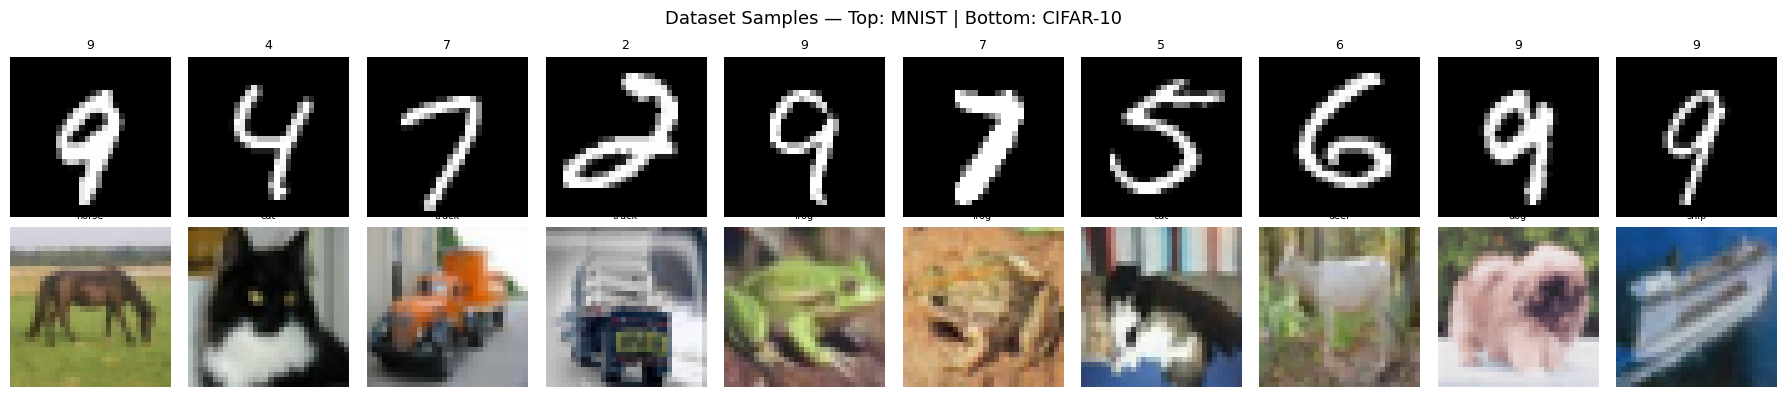

Saved dataset_samples.png


In [ ]:
#Problem 2: Dataset Exploration

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mn, y_train_mn), (x_test_mn, y_test_mn) = mnist.load_data()
(x_train_cf, y_train_cf), (x_test_cf, y_test_cf) = cifar10.load_data()

print("\n--- MNIST ---")
print("Train X shape:", x_train_mn.shape)
print("Test  X shape:", x_test_mn.shape)
print("Train y shape:", y_train_mn.shape)
print("Test  y shape:", y_test_mn.shape)

print("\n--- CIFAR-10 ---")
print("Train X shape:", x_train_cf.shape)
print("Test  X shape:", x_test_cf.shape)
print("Train y shape:", y_train_cf.shape)
print("Test  y shape:", y_test_cf.shape)

print("\n--- Data types & ranges (raw) ---")
print("MNIST   dtype:", x_train_mn.dtype, " | min:", x_train_mn.min(), " max:", x_train_mn.max())
print("CIFAR10 dtype:", x_train_cf.dtype, " | min:", x_train_cf.min(), " max:", x_train_cf.max())

print("\n--- MNIST class distribution (training) ---")
unique, counts = np.unique(y_train_mn, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count} samples")

cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Dataset Samples — Top: MNIST | Bottom: CIFAR-10", fontsize=13)

mn_idx = random.sample(range(len(x_train_mn)), 10)
cf_idx = random.sample(range(len(x_train_cf)), 10)

for col in range(10):
    axes[0, col].imshow(x_train_mn[mn_idx[col]], cmap='gray')
    axes[0, col].set_title(str(y_train_mn[mn_idx[col]]), fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(x_train_cf[cf_idx[col]])
    axes[1, col].set_title(cifar_classes[y_train_cf[cf_idx[col]][0]], fontsize=7)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=120)
plt.show()
print("Saved dataset_samples.png")

MNIST: Train shape (60000, 28, 28), Test shape (10000, 28, 28)

CIFAR-10: Train shape (50000, 32, 32, 3), Test shape (10000, 32, 32, 3)

Dtype: uint8, Value range: 0-255

MNIST classes are balanced (~6000 samples per class)

In [ ]:
#Problem 3: Preprocessing Pipeline

def preprocess(images, labels, num_classes=10):
    print("Before normalise — dtype:", images.dtype, " min:", images.min(), " max:", images.max())
    images = images.astype(np.float32) / 255.0
    print("After  normalise — dtype:", images.dtype, " min:", round(images.min(),4), " max:", round(images.max(),4))
    if images.ndim == 3:
        images = images[..., np.newaxis]
    print("After  reshape   — shape:", images.shape)
    labels = labels.flatten()
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    for i, lbl in enumerate(labels):
        one_hot[i, lbl] = 1.0
    print("After  one-hot   — shape:", one_hot.shape, " sample:", one_hot[0])
    return images, one_hot

print("\n--- Preprocessing MNIST ---")
x_train_mn_p, y_train_mn_p = preprocess(x_train_mn, y_train_mn)
x_test_mn_p,  y_test_mn_p  = preprocess(x_test_mn,  y_test_mn)

print("\n--- Preprocessing CIFAR-10 ---")
x_train_cf_p, y_train_cf_p = preprocess(x_train_cf, y_train_cf)
x_test_cf_p,  y_test_cf_p  = preprocess(x_test_cf,  y_test_cf)


--- Preprocessing MNIST ---
Before normalise — dtype: uint8  min: 0  max: 255
After  normalise — dtype: float32  min: 0.0  max: 1.0
After  reshape   — shape: (60000, 28, 28, 1)
After  one-hot   — shape: (60000, 10)  sample: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Before normalise — dtype: uint8  min: 0  max: 255
After  normalise — dtype: float32  min: 0.0  max: 1.0
After  reshape   — shape: (10000, 28, 28, 1)
After  one-hot   — shape: (10000, 10)  sample: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

--- Preprocessing CIFAR-10 ---
Before normalise — dtype: uint8  min: 0  max: 255
After  normalise — dtype: float32  min: 0.0  max: 1.0
After  reshape   — shape: (50000, 32, 32, 3)
After  one-hot   — shape: (50000, 10)  sample: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Before normalise — dtype: uint8  min: 0  max: 255
After  normalise — dtype: float32  min: 0.0  max: 1.0
After  reshape   — shape: (10000, 32, 32, 3)
After  one-hot   — shape: (10000, 10)  sample: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


Before normalization: dtype=uint8, range [0, 255]

After normalization: dtype=float32, range [0.0, 1.0]

Before reshape: (60000, 28, 28)

After reshape: (60000, 28, 28, 1)

Before one-hot: integer labels [0-9]

After one-hot: vectors of length 10

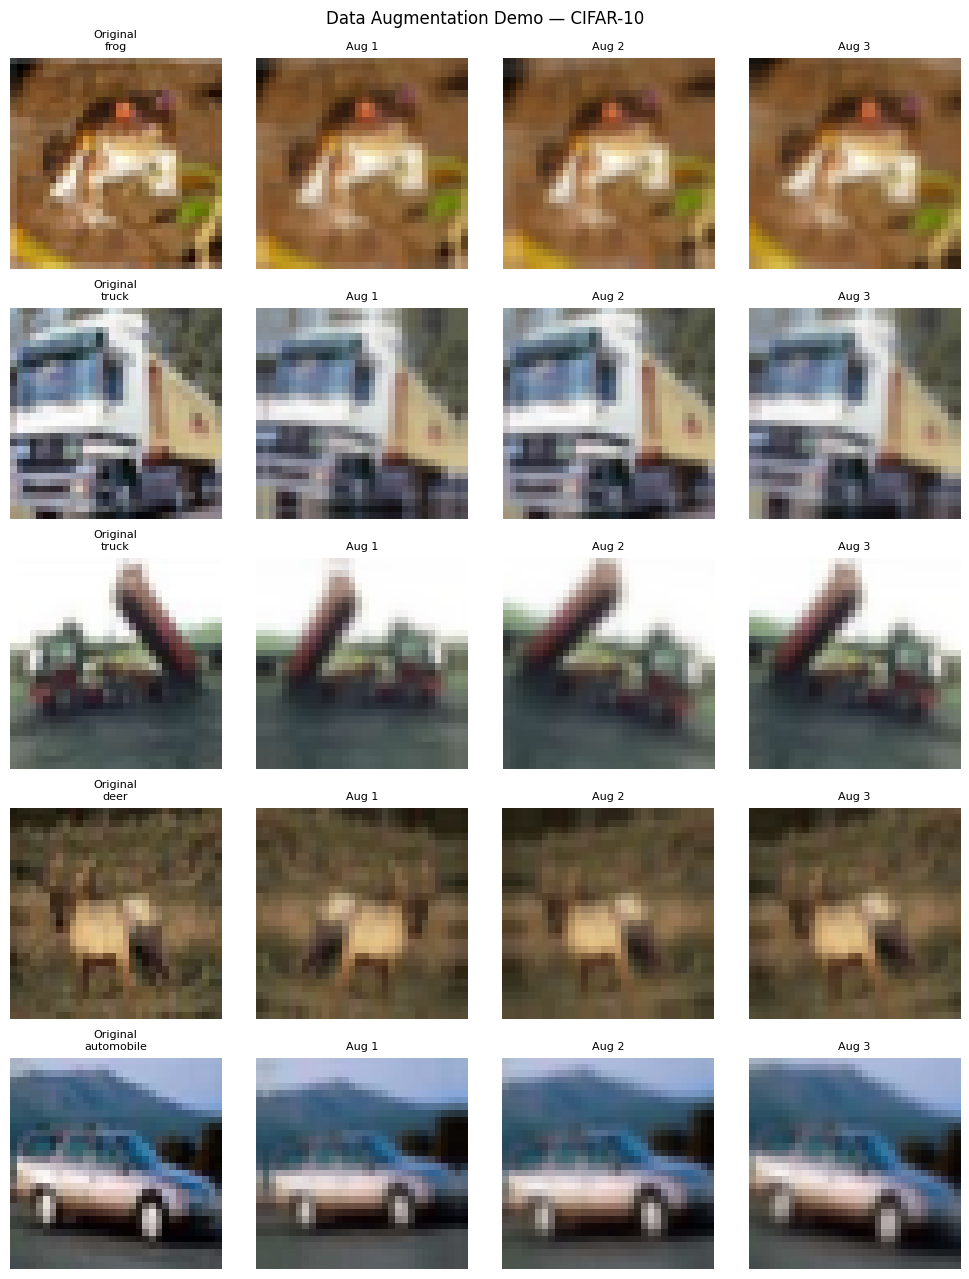

Saved augmentation_demo.png


In [ ]:
#Problem 4: Data Augmentation Pipeline

import tensorflow as tf
rotation_layer = tf.keras.layers.RandomRotation(factor=0.03)
zoom_layer = tf.keras.layers.RandomZoom(height_factor=(-0.10, 0.10))

def augment_cifar(image):
    image = tf.image.random_flip_left_right(image)
    image = rotation_layer(tf.expand_dims(image, 0), training=True)[0]
    image = zoom_layer(tf.expand_dims(image, 0), training=True)[0]
    return image

fig, axes = plt.subplots(5, 4, figsize=(10, 13))
fig.suptitle("Data Augmentation Demo — CIFAR-10", fontsize=12)

for row in range(5):
    orig = x_train_cf_p[row]
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"Original\n{cifar_classes[y_train_cf[row][0]]}", fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 4):
        aug = augment_cifar(orig).numpy()
        aug = np.clip(aug, 0, 1)
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f"Aug {col}", fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=120)
plt.show()
print("Saved augmentation_demo.png")

Augmentation must only be applied to training set because validation
and test sets must represent real-world data exactly as it is.
Augmenting test data would change the distribution and give
unreliable accuracy measurements.

**ANALYSIS & REFLECTION QUESTIONS**

**Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)? Explain with reference toboth a greyscale image and an RGB image**

The C in (N, H, W, C) represents color channels. A greyscale image
has C=1 (only intensity values). An RGB image has C=3 (red, green,
blue channels). Each channel stores pixel intensity for that color.

**Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images, what data loading strategies would you use to avoid running out of memory? Name at least two techniques and explain how each one helps**

1. Use data generators/tf.data pipeline - load images in batches
   instead of all at once, saving RAM.
2. Use image tiling - split large images into smaller patches and
   process each patch separately.

**Q3. Suppose a student applies normalisation to the test set using the mean and standard deviation computed from the test set itself. What is wrong with this approach?**

This is data leakage. Test set statistics should never influence
preprocessing. Normalization must always use mean and std computed
from the training set only, then applied to both train and test sets.